This notebook provides a graphical analysis of all the data stratified by undergraduate (INFO284  + INF266) and graduate (IGSIN919) participants collected during the survey.

Some of this code (especially the optimized visualization) was generated with the support of Anthropic Claude. No data was shared or uploade to Anthropic Claude.

### Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data loading

In [3]:
df = pd.read_csv('data.csv', encoding='latin-1')
df.head()

,Group,"1. On average, how many hours per week do you use AI tools for this course?\n",2. Which AI tools do you regularly use for this course? - ChatGPT,2. Which AI tools do you regularly use for this course? - Gemini,2. Which AI tools do you regularly use for this course? - Claude,2. Which AI tools do you regularly use for this course? - Copilot,2. Which AI tools do you regularly use for this course? - DeepSeek,2. Which AI tools do you regularly use for this course? - Grok,2. Which AI tools do you regularly use for this course? - Other (specify),2. Which AI tools do you regularly use for this course? - Other (specify).1,...,8. How do you think of an AI tool while interacting with it? - A text or code generator,8. How do you think of an AI tool while interacting with it? - A knowledge interface,8. How do you think of an AI tool while interacting with it? - Other (specify),8. How do you think of an AI tool while interacting with it? - Other (specify).1,"Thank you for participating in the survey! If you have any comments regarding the survey, you can leave them here.",Overall Status - New,Overall Status - Distributed,Overall Status - Partially Complete,Overall Status - Complete,Overall Status - Rejected
0,INFO284,More than 6,1,0,0,1,0,0,1,Github copilot,...,0,1,0,NaN,NaN,0,0,0,1,0
1,INFO284,1-2,1,0,1,1,0,0,0,NaN,...,1,0,0,NaN,NaN,0,0,0,1,0
2,INFO284,2-4,1,0,0,0,0,0,0,NaN,...,0,0,0,NaN,NaN,0,0,0,1,0
3,INFO284,2-4,1,0,1,0,0,0,0,NaN,...,0,0,0,NaN,NaN,0,0,0,1,0
4,INFO284,4-6,1,0,1,0,0,0,0,NaN,...,1,0,0,NaN,NaN,0,0,0,1,0


### Question 1

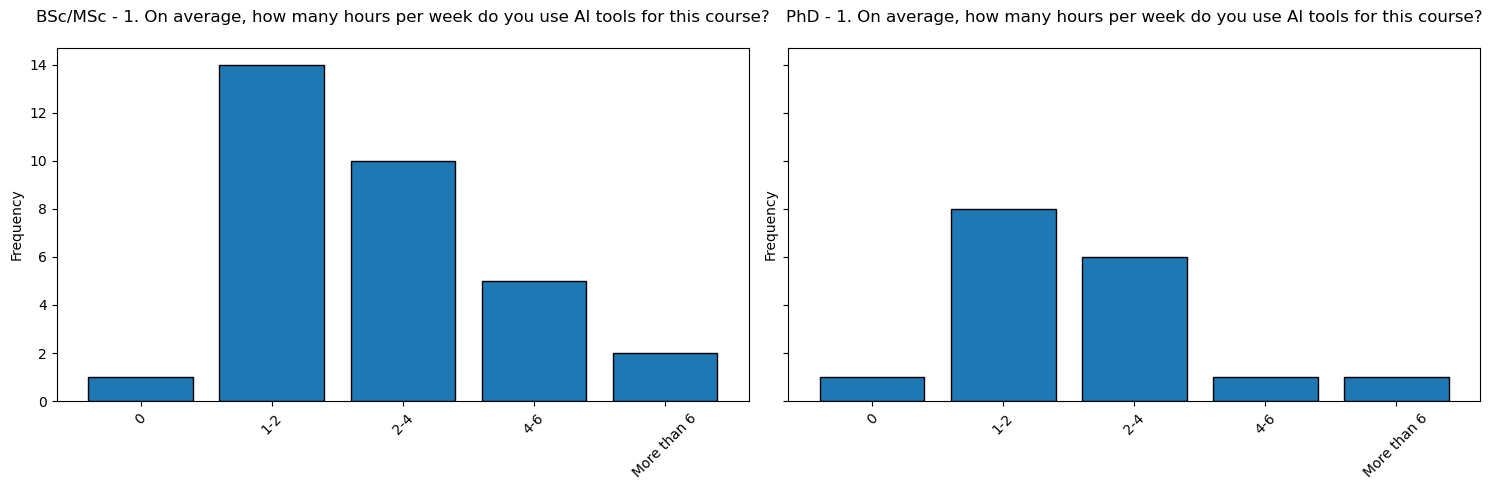

In [12]:
custom_order = ['0', '1-2', '2-4', '4-6', 'More than 6']  # replace with your actual categories
phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    
    # Count occurrences, then reindex to your order
    counts = filtered.iloc[:, 1].value_counts()
    counts = counts.reindex(custom_order)

    # Plot
    ax.bar(counts.index, counts.values, edgecolor='black')  # fix: ax.bar not ax.plot
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{phdlabels[i]} - {df.iloc[:, 1].name}')
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

### Question 2

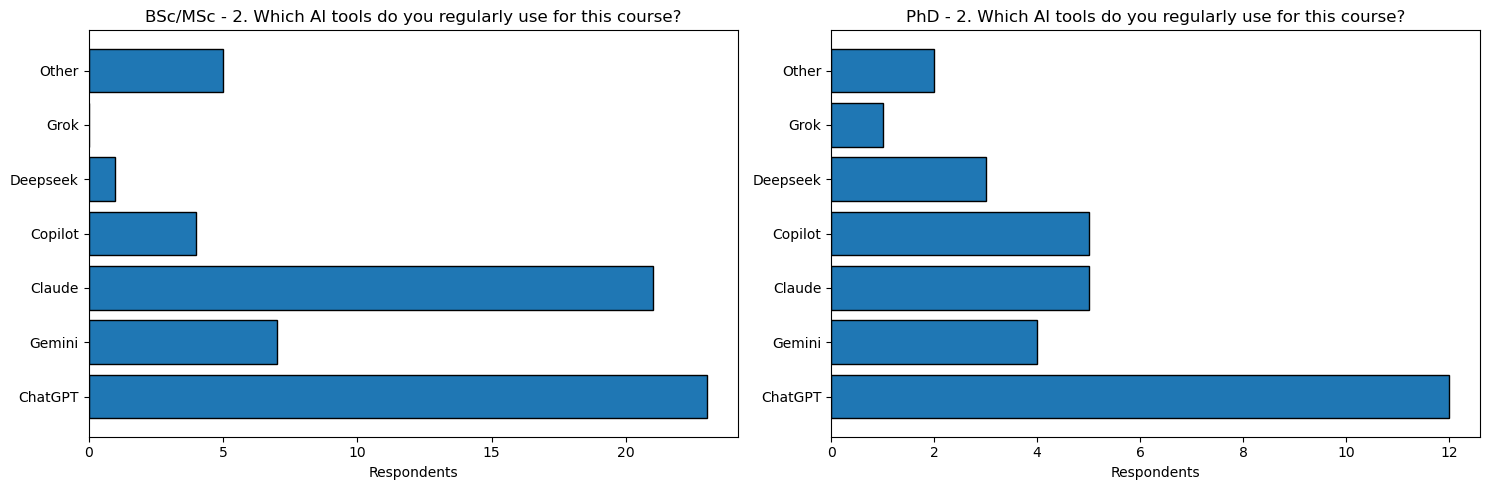

In [16]:
labels = ['ChatGPT', 'Gemini', 'Claude', 'Copilot', 'Deepseek', 'Grok', 'Other']
phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    sums = [filtered.iloc[:, i].sum() for i in np.arange(2,9)]
    
    # Plot
    ax.barh(labels, sums, edgecolor='black')
    ax.set_xlabel('Respondents')
    ax.set_title(f'{phdlabels[i]} - 2. Which AI tools do you regularly use for this course?')
    
plt.tight_layout()
plt.show()

### Question 3

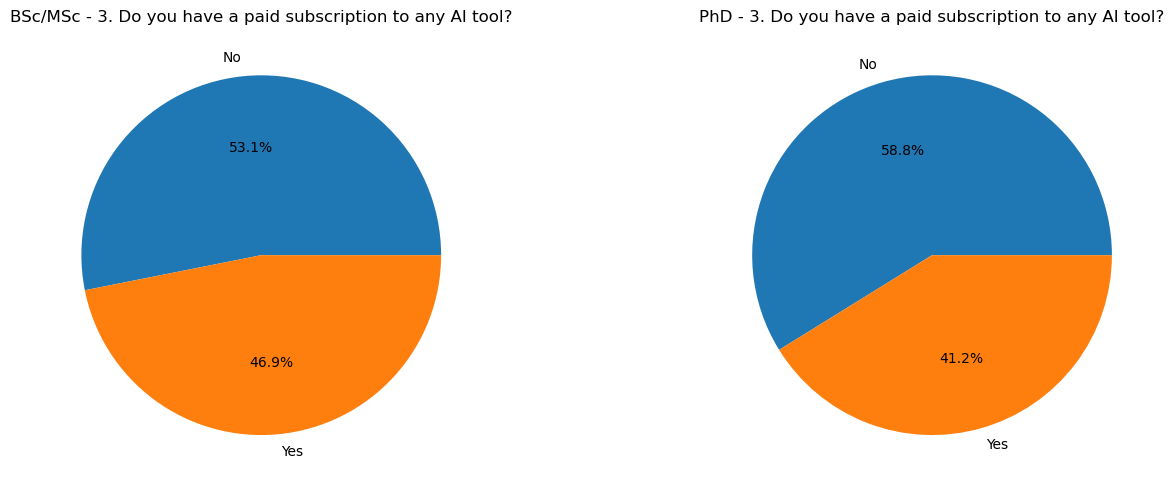

In [21]:
col10 = df.iloc[:, 10]

phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    
    # Plot
    counts = filtered.iloc[:, 10].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
    ax.set_title(f'{phdlabels[i]} - {col10.name}')
    
plt.tight_layout()
plt.show()


### Question 4

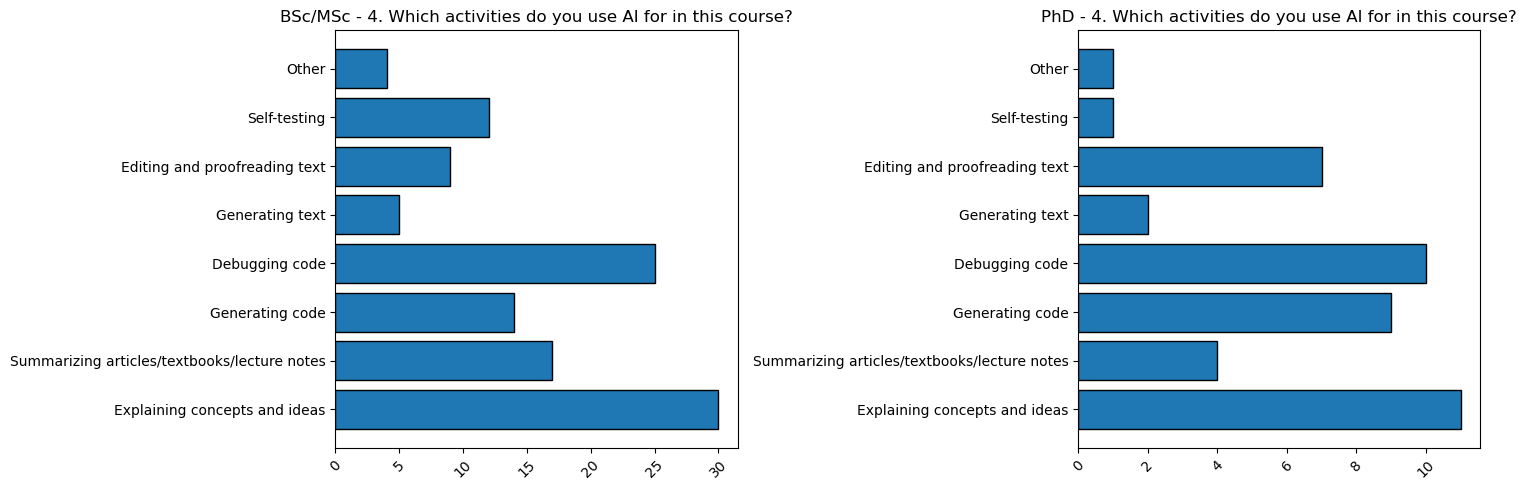

In [23]:
labels = ['Explaining concepts and ideas',
          'Summarizing articles/textbooks/lecture notes',
          'Generating code', 
          'Debugging code',
          'Generating text',
          'Editing and proofreading text',
          'Self-testing',
          'Other']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    sums = [filtered.iloc[:, i].sum() for i in np.arange(11,19)]
    ax.barh(labels, sums, edgecolor='black')
    ax.set_title(f'{phdlabels[i]} - 4. Which activities do you use AI for in this course?')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Question 5

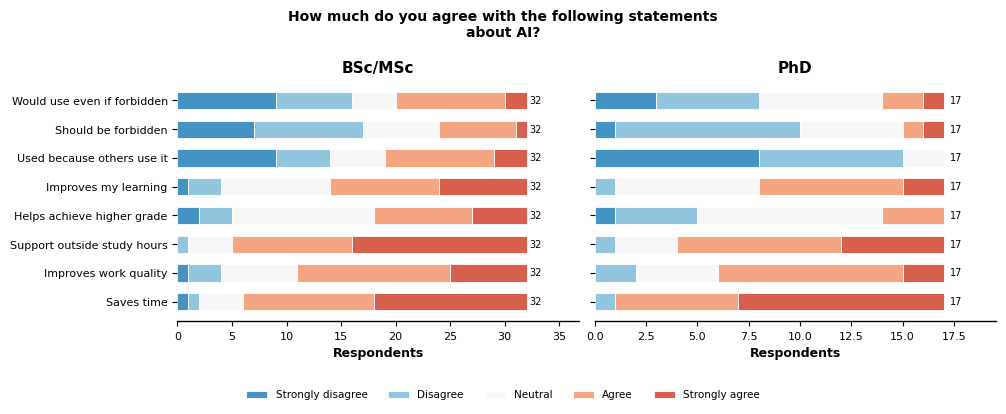

In [4]:
import textwrap
import matplotlib.pyplot as plt
import numpy as np

short_labels = [
    'Saves time',
    'Improves work quality',
    'Support outside study hours',
    'Helps achieve higher grade',
    'Improves my learning',
    'Used because others use it',
    'Should be forbidden',
    'Would use even if forbidden',
]

data_keys      = ['Strongly disagree', 'Disagree', 'Neither agree nor disagree', 'Agree', 'Strongly agree']
display_labels = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']
colors         = ['#4393c3', '#92c5de', '#f7f7f7', '#f4a582', '#d6604d']

val1, val2     = 'INF', 'IGSIN'
group_labels   = ['BSc/MSc', 'PhD']

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

for ax, val, group in zip(axes, [val1, val2], group_labels):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    cols     = [filtered.iloc[:, i] for i in range(20, 28)]

    # Build data matrix for this group
    data = np.array([
        col.value_counts().reindex(data_keys, fill_value=0).values
        for col in cols
    ])

    y_pos = np.arange(len(short_labels))
    lefts = np.zeros(len(short_labels))

    for j, (display, color) in enumerate(zip(display_labels, colors)):
        ax.barh(
            y_pos, data[:, j], left=lefts,
            color=color, edgecolor='white',
            linewidth=0.6, height=0.6, label=display,
        )
        lefts += data[:, j]

    # Total count labels
    for i, total in enumerate(data.sum(axis=1)):
        ax.text(total + 0.3, i, str(int(total)),
                va='center', ha='left', fontsize=7)

    ax.set_title(group, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('Respondents', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlim(0, data.sum(axis=1).max() * 1.15)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)

# Y-axis labels only on the left panel (sharey=True shares them)
axes[0].set_yticks(np.arange(len(short_labels)))
axes[0].set_yticklabels(short_labels, fontsize=8)

# Shared title
fig.suptitle(
    '\n'.join(textwrap.wrap('How much do you agree with the following statements about AI?', width=55)),
    fontsize=10, fontweight='bold', y=1.02,
)

# Single shared legend below both panels
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(
    handles, display_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=5, fontsize=7.5, frameon=False,
)

plt.tight_layout(pad=0.5)
plt.savefig('poster_agreement_split.png', dpi=300, bbox_inches='tight')
plt.show()

### Question 6

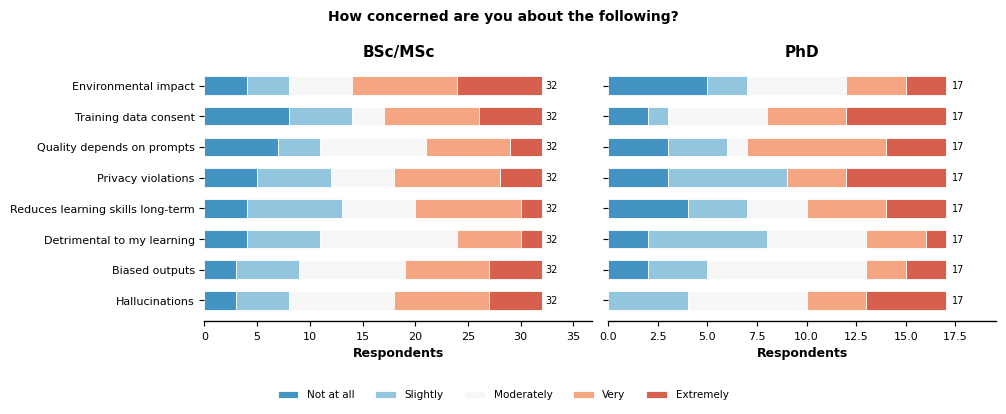

In [7]:
import textwrap
import matplotlib.pyplot as plt
import numpy as np

short_labels = [
    'Hallucinations',
    'Biased outputs',
    'Detrimental to my learning',
    'Reduces learning skills long-term',
    'Privacy violations',
    'Quality depends on prompts',
    'Training data consent',
    'Environmental impact',
]

data_keys      = ['No at all concerned', 'Slightly concerned', 'Moderately concerned', 'Very concerned', 'Extremely concerned']
display_labels = ['Not at all', 'Slightly', 'Moderately', 'Very', 'Extremely']
colors         = ['#4393c3', '#92c5de', '#f7f7f7', '#f4a582', '#d6604d']

val1, val2   = 'INF', 'IGSIN'
group_labels = ['BSc/MSc', 'PhD']

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

for ax, val, group in zip(axes, [val1, val2], group_labels):
    filtered = df[df.iloc[:, 0].str.contains(val)]
    cols     = [filtered.iloc[:, i] for i in range(28, 36)]

    data = np.array([
        col.value_counts().reindex(data_keys, fill_value=0).values
        for col in cols
    ])

    y_pos = np.arange(len(short_labels))
    lefts = np.zeros(len(short_labels))

    for j, (display, color) in enumerate(zip(display_labels, colors)):
        ax.barh(
            y_pos, data[:, j], left=lefts,
            color=color, edgecolor='white',
            linewidth=0.6, height=0.6, label=display,
        )
        lefts += data[:, j]

    # Total count labels
    for i, total in enumerate(data.sum(axis=1)):
        ax.text(total + 0.3, i, str(int(total)),
                va='center', ha='left', fontsize=7)

    ax.set_title(group, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('Respondents', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlim(0, data.sum(axis=1).max() * 1.15)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)

axes[0].set_yticks(np.arange(len(short_labels)))
axes[0].set_yticklabels(short_labels, fontsize=8)

fig.suptitle(
    '\n'.join(textwrap.wrap('How concerned are you about the following?', width=55)),
    fontsize=10, fontweight='bold', y=1.02,
)

handles, _ = axes[0].get_legend_handles_labels()
fig.legend(
    handles, display_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=5, fontsize=7.5, frameon=False,
)

plt.tight_layout(pad=0.5)
plt.savefig('poster_concern_split.png', dpi=300, bbox_inches='tight')
plt.show()

### Question 7

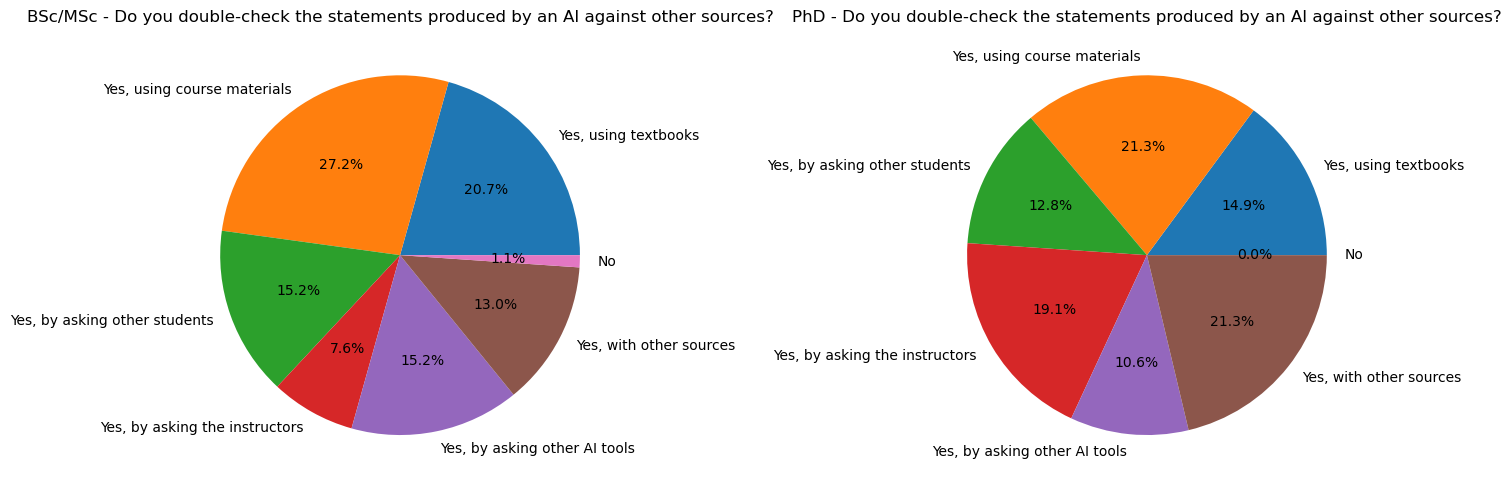

In [27]:
col10 = df.iloc[:, 36:43]
labels = ['Yes, using textbooks',
         'Yes, using course materials',
         'Yes, by asking other students',
         'Yes, by asking the instructors',
         'Yes, by asking other AI tools',
         'Yes, with other sources',
         'No']

phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = col10[df.iloc[:, 0].str.contains(val)]
    
    # Plot
    sums = filtered.sum()    
    ax.pie(sums.values, labels=labels, autopct='%1.1f%%')
    ax.set_ylabel('')  # hides the default y-label
    ax.set_title(f'{phdlabels[i]} - Do you double-check the statements produced by an AI against other sources?')
    
plt.tight_layout()
plt.show()



### Question 8

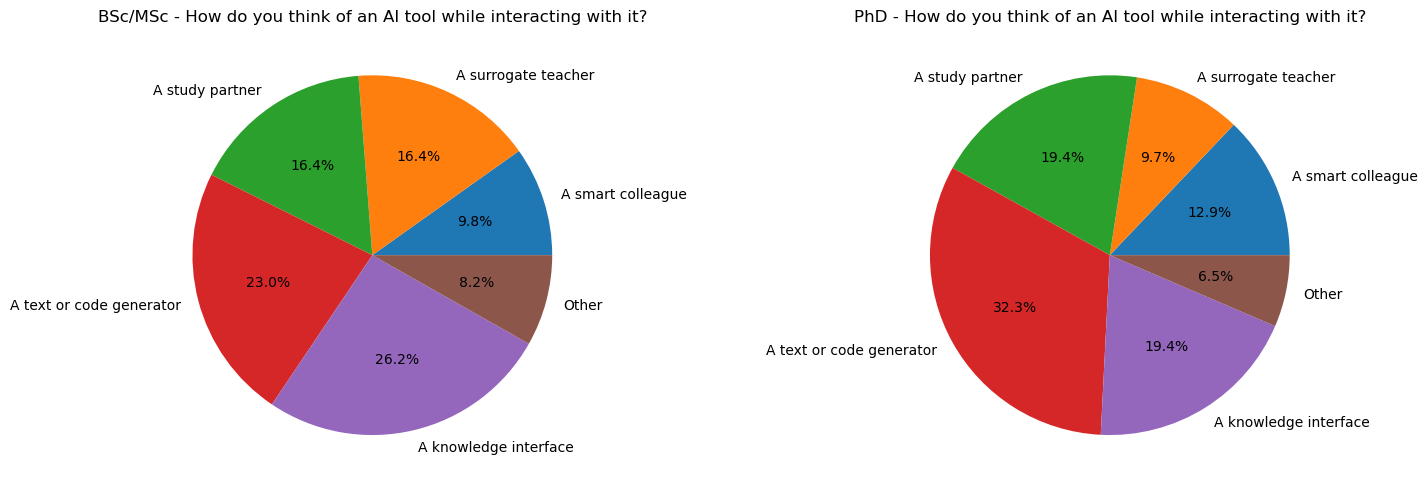

In [28]:
col10 = df.iloc[:, 44:50]
labels = ['A smart colleague',
         'A surrogate teacher',
         'A study partner',
         'A text or code generator',
         'A knowledge interface',
         'Other']

phdlabels = ['BSc/MSc', 'PhD']

val1, val2 = 'INF', 'IGSIN'  # replace with your actual values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, val, i in zip(axes, [val1, val2], range(len(labels))):
    filtered = col10[df.iloc[:, 0].str.contains(val)]
    
    # Plot
    sums = filtered.sum()    
    ax.pie(sums.values, labels=labels, autopct='%1.1f%%')
    ax.set_ylabel('')  # hides the default y-label
    ax.set_title(f'{phdlabels[i]} - How do you think of an AI tool while interacting with it?')

plt.tight_layout()
plt.show()